In [1]:
import pandas as pd
import numpy as np
df={
    "Size_sqft": [850,900,950,1000,1100,1200,1250,1300,1400,1500,
                  1600,1700,1800,1900,2000,2100,2200,2300,2400,2500],

    "Bedrooms": [2,2,2,2,3,3,3,3,3,3,
                 4,4,4,4,4,4,5,5,5,5],

    "Age_years": [15,12,10,8,10,8,7,6,5,4,
                  5,4,3,3,2,2,3,2,2,1],

    "Distance_km": [8.5,7.8,7.0,6.5,6.0,5.5,5.0,4.5,4.0,3.5,
                    3.0,2.8,2.5,2.0,1.8,1.5,1.2,1.0,0.8,0.5],

    "Price": [32,35,38,42,46,50,54,58,63,68,
              73,78,84,90,96,102,108,115,122,130]
}
data=pd.DataFrame(df)
print(data.head())

   Size_sqft  Bedrooms  Age_years  Distance_km  Price
0        850         2         15          8.5     32
1        900         2         12          7.8     35
2        950         2         10          7.0     38
3       1000         2          8          6.5     42
4       1100         3         10          6.0     46


In [2]:
print(data.tail())

    Size_sqft  Bedrooms  Age_years  Distance_km  Price
15       2100         4          2          1.5    102
16       2200         5          3          1.2    108
17       2300         5          2          1.0    115
18       2400         5          2          0.8    122
19       2500         5          1          0.5    130


In [3]:
print(data["Price"].head())

0    32
1    35
2    38
3    42
4    46
Name: Price, dtype: int64


In [4]:
print("Original Data shape :",data.shape)
X=data.drop("Price",axis=1)
y=data["Price"]
print("X shape : ",X.shape)
print("y shape : ",y.shape)

Original Data shape : (20, 5)
X shape :  (20, 4)
y shape :  (20,)


In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
tree=DecisionTreeRegressor(max_depth=2)
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.4,
                                              random_state=42)
print("X_train : \n",X_train ,"\nshape : ",X_train.shape)
print("X_test : \n",X_test,"\nshape : ",X_test.shape)
print("y_train : \n",y_train,"\nshape : ",y_train.shape)
print("y_test : \n",y_test,"\nshape : ",y_test.shape)

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print("X_train_scaled :\n",X_train_scaled)
print("X_test_scaled :\n",X_test_scaled)

tree.fit(X_train_scaled,y_train)
y_pred=tree.predict(X_test_scaled)
print("y_pred : \n",y_pred)

X_train : 
     Size_sqft  Bedrooms  Age_years  Distance_km
18       2400         5          2          0.8
16       2200         5          3          1.2
13       1900         4          3          2.0
2         950         2         10          7.0
9        1500         3          4          3.5
19       2500         5          1          0.5
4        1100         3         10          6.0
12       1800         4          3          2.5
7        1300         3          6          4.5
10       1600         4          5          3.0
14       2000         4          2          1.8
6        1250         3          7          5.0 
shape :  (12, 4)
X_test : 
     Size_sqft  Bedrooms  Age_years  Distance_km
0         850         2         15          8.5
17       2300         5          2          1.0
15       2100         4          2          1.5
1         900         2         12          7.8
8        1400         3          5          4.0
5        1200         3          8          5.5

In [30]:
comparison=pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})
print(comparison)

    Actual   Predicted
0       32   46.000000
17     115  120.000000
15     102   90.000000
1       35   46.000000
8       63   66.333333
5       50   46.000000
11      78   90.000000
3       42   46.000000


SINGLE DECISION TREE
--------------------
MAE :  84.13888888888889
MSE :  84.13888888888889
RMSE :  9.172725270544674
R2 :  0.9007777839197935


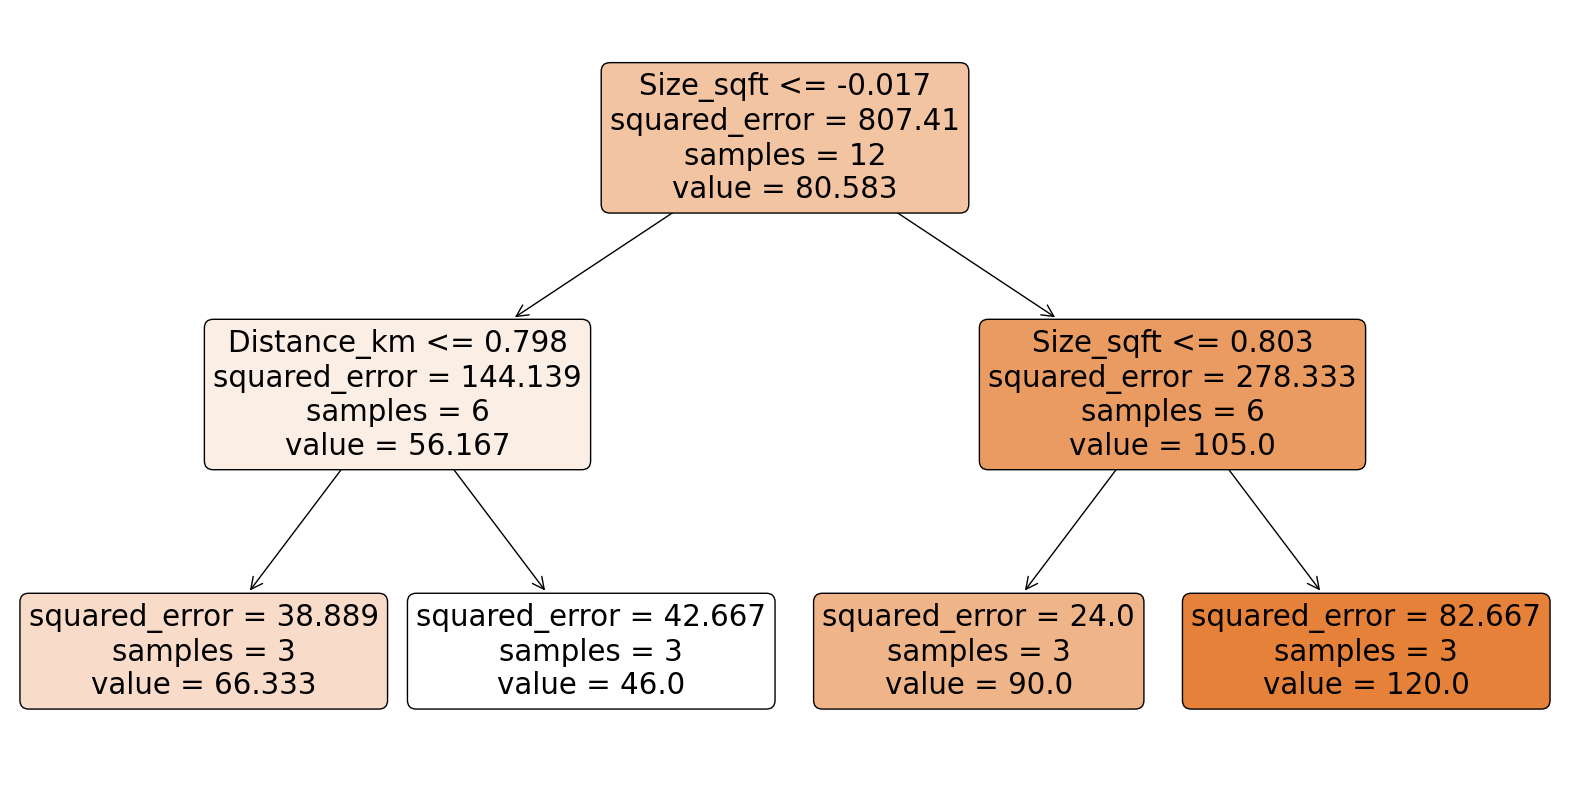

In [32]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
print("SINGLE DECISION TREE")
print("--------------------")
print("MAE : " ,mean_squared_error(y_test,y_pred))
print("MSE : " ,mean_squared_error(y_test,y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 : ",r2_score(y_test,y_pred))
plt.figure(figsize=(20,10))
plot_tree(tree,feature_names=X.columns,filled=True,rounded=True)
plt.show()
    


In [8]:
from sklearn.ensemble import RandomForestRegressor
forest=RandomForestRegressor(n_estimators=100,random_state=42)
forest.fit(X_train_scaled,y_train)
y_pred_rf=forest.predict(X_test_scaled)
print(y_pred_rf)

[ 41.99 115.12  97.7   41.99  61.7   52.87  76.95  46.63]


In [9]:
comparison["New Predicted"]=y_pred_rf
print(comparison)

    Actual  Predicted  New Predicted
0       32       38.0          41.99
17     115      122.0         115.12
15     102      108.0          97.70
1       35       38.0          41.99
8       63       58.0          61.70
5       50       54.0          52.87
11      78       68.0          76.95
3       42       54.0          46.63


In [10]:
from sklearn.metrics import r2_score

r2_forest = r2_score(y_test, y_pred_rf)

print("Random Forest R²:", r2_forest)

Random Forest R²: 0.9705727331355605


In [11]:
from sklearn.metrics import r2_score

train_pred_tree = tree.predict(X_train_scaled)
test_pred_tree = tree.predict(X_test_scaled)

print("Decision Tree Train R2:",
      r2_score(y_train, train_pred_tree))

print("Decision Tree Test R2:",
      r2_score(y_test, test_pred_tree))

Decision Tree Train R2: 1.0
Decision Tree Test R2: 0.9388255237603876


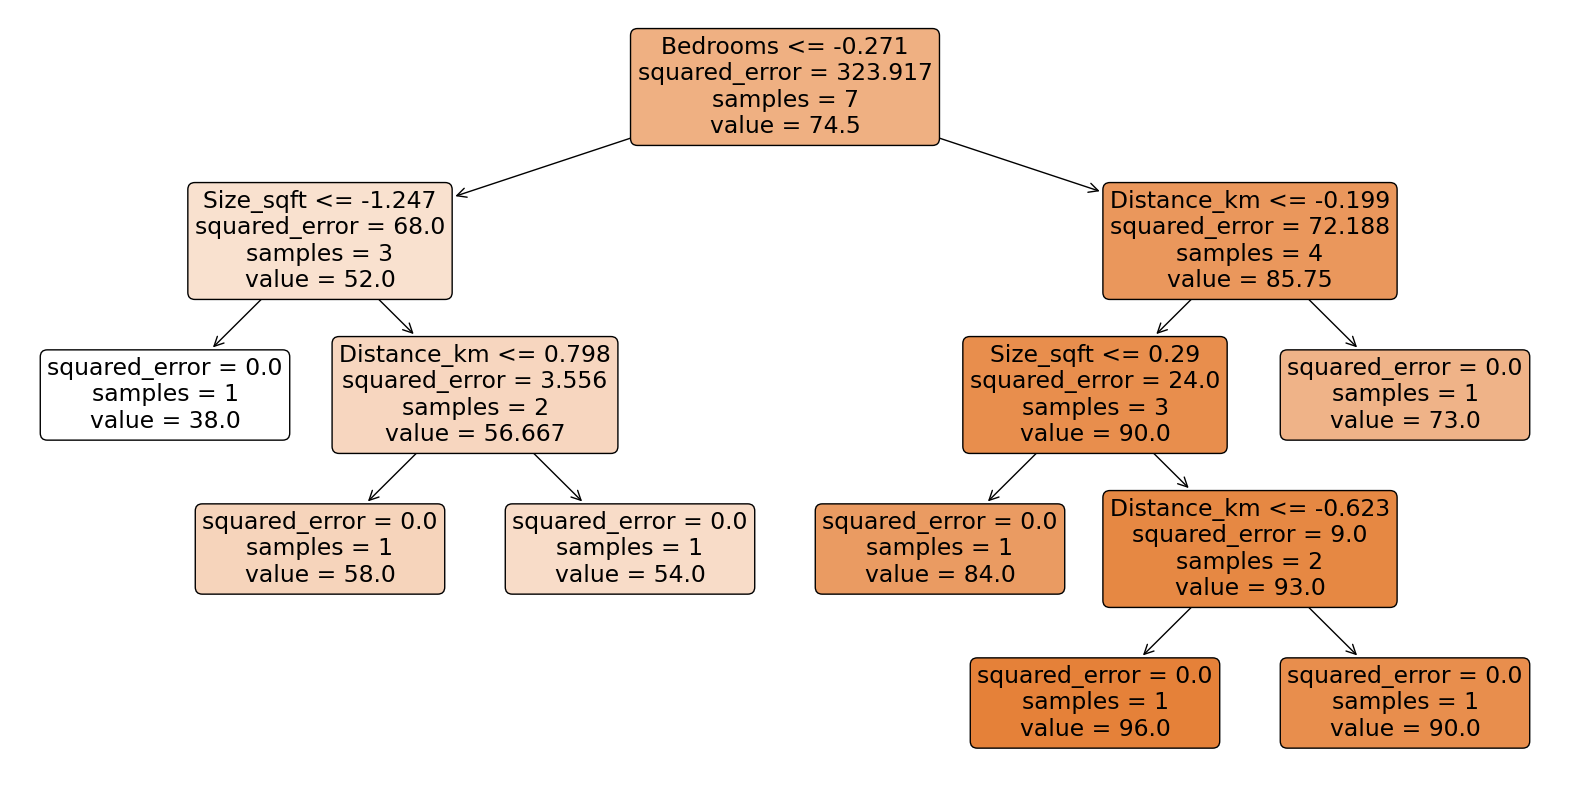

In [34]:
plt.figure(figsize=(20, 10))

plot_tree(
    forest.estimators_[0],
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.show()